# Q5：大市值因子有效性研究（CSI 300）

## 研究背景
Q3 在微盘股（861520.EI）发现：基本面越差越抗跌、PB 是估值陷阱、动量方向 50% 随机。
Q5 用同一套方法论检验沪深 300——**大市值池子里，教科书逻辑是否成立？**

## 样本池
- **CSI 300 成分股**：Choice 终端导出，~300 只
- 市值范围：~254 亿 ~ 27,442 亿，中位数 ~1,058 亿
- 28 个申万一级行业全覆盖

## 研究设计
1. 加载成分股 + 日K（2025-2026）+ 最新财务数据
2. t 检验 / MWU / Logit / 五分位 / 行业矩阵 / 市值分层，七层验证
3. 与 Q3 微盘做因子方向对比
4. V1 纯截面分析——多年回溯因成分股调整搁置至 V2

## 关键假设
- EPS/ROE 方向预期反转：高 → 抗跌（vs 微盘低 → 抗跌）
- PB 方向预期反转：低 → 抗跌
- 波动率：实测高波→抗跌（t=+4.54, p<.001）— 与微盘方向反转
- 动量在大盘可能更稳定

In [153]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

CACHE = Path('research_cache')
print('就绪')


就绪


## Step 1: 加载 CSI 300 成分股

数据来源：`成分详情(000300.SH).xlsx`（Choice 终端导出），含证券代码、总市值、流通市值、申万一级行业、纳入日期。

In [154]:
# === 加载 CSI 300 成分股 ===
XLSX = '成分详情(000300.SH).xlsx'
df = pd.read_excel(XLSX, dtype={'证券代码': str})

# 标准化股票代码：300308.SZ → 300308
df['stock_code'] = df['证券代码'].astype(str).str[:6]
df = df[df['stock_code'].str.len() == 6].copy()

# 重命名列
df = df.rename(columns={
    '证券简称': 'name',
    '总市值(亿元)': 'total_mv',
    '自由流通市值(亿元)': 'float_mv',
    '申万一级行业': 'industry',
    '纳入日期': 'inclusion_date',
    '收盘价': 'close',
    '涨跌幅(%)': 'pct_chg',
})

print(f'CSI 300: {len(df)} 只')
print(f'  总市值: {df["total_mv"].min():.0f} ~ {df["total_mv"].max():.0f} 亿')
print(f'  中位数: {df["total_mv"].median():.0f} 亿')
print(f'  行业数: {df["industry"].nunique()}')
print()

print('市值前10:')
top10 = df.nlargest(10, 'total_mv')[['name','stock_code','total_mv','industry']]
for _, row in top10.iterrows():
    print(f'  {row["name"]} ({row["stock_code"]}) | {row["total_mv"]:.0f}亿 | {row["industry"]}')
df.head(3)


CSI 300: 300 只
  总市值: 254 ~ 27442 亿
  中位数: 1058 亿
  行业数: 28

市值前10:
  建设银行 (601939) | 27442亿 | 银行
  工商银行 (601398) | 27408亿 | 银行
  农业银行 (601288) | 23484亿 | 银行
  中国移动 (600941) | 21088亿 | 通信
  中国银行 (601988) | 20042亿 | 银行
  中国石油 (601857) | 18741亿 | 石油石化
  宁德时代 (300750) | 17974亿 | 电力设备
  中国海油 (600938) | 16184亿 | 石油石化
  贵州茅台 (600519) | 15950亿 | 食品饮料
  工业富联 (601138) | 14115亿 | 电子


,排序,证券代码,name,close,涨跌,pct_chg,成交量(万股),成交额(万元),权重(%),贡献点,float_mv,total_mv,自由流通股本(亿),总股本(亿),industry,inclusion_date,stock_code
0,1,300308.SZ,中际旭创,1147.00,-33.00,-2.80,2289.65,2638250.18,4.83,-7.42,12744.53,12791.74,11.11,11.15,通信,2023-12-11,300308
1,2,300750.SZ,宁德时代,388.50,-11.00,-2.75,2443.57,953558.12,4.20,-6.35,10274.25,17974.45,26.45,46.27,电力设备,2021-12-13,300750
2,3,600519.SH,贵州茅台,1275.88,19.88,1.58,392.44,499168.64,3.11,2.70,7988.73,15949.54,6.26,12.50,食品饮料,2005-04-08,600519


## Step 2: 加载价格数据

使用 akshare 腾讯接口 `stock_zh_a_hist_tx` 拉取 2025 全年 + 2026 YTD 日K，计算：
- `ret_2025`：2025 全年收益率（首尾价格比）
- `vol_2025`：2025 年化波动率（日对数收益率 std × √252）
- `ytd_ret_2026`：2026 年至今收益率

In [155]:
# === 加载价格数据 ===
PRICE_CACHE = CACHE / 'q5_price_csi300.csv'

if PRICE_CACHE.exists():
    price = pd.read_csv(PRICE_CACHE, dtype={'stock_code': str})
else:
    print('?? 价格缓存不存在，请先运行 gen_data_large_mid.py')
    price = pd.DataFrame()

if len(price) > 0:
    print(f'从缓存加载价格: {len(price)} 只')
    print(f'  2026YTD 均值: {price["ytd_ret_2026"].mean()*100:.1f}%')
    print(f'  2026YTD 中位数: {price["ytd_ret_2026"].median()*100:.1f}%')
    print(f'  2025收益 均值: {price["ret_2025"].mean()*100:.1f}%')
    print(f'  2025波动率 均值: {price["vol_2025"].mean():.3f}')
    n_res = (price['ytd_ret_2026'] > 0).sum()
    print(f'  抗跌(YTD>0): {n_res}/{len(price)} ({n_res/len(price)*100:.0f}%)')
price.head(3)


从缓存加载价格: 300 只
  2026YTD 均值: 0.4%
  2026YTD 中位数: -6.9%
  2025收益 均值: 23.9%
  2025波动率 均值: 0.331
  抗跌(YTD>0): 107/300 (36%)


,stock_code,ytd_ret_2026,ret_2025,vol_2025
0,000001,-0.071304,-0.001750,0.159118
1,000002,-0.271579,-0.345992,0.326053
2,000063,-0.068235,-0.002373,0.500426


## Step 3: 加载财务数据

| 字段 | 来源 | 覆盖率 | 格式 | 备注 |
|------|------|:--:|:--:|------|
|  | baostock profit_data[7] | 100% | decimal | 每股收益，原始值 |
|  | baostock profit_data[3] | 100% | decimal | notebook 自动 /100 处理百分比混入 |
|  | baostock growth_data[4] | ~100% | 混合 | **已 winsorize **，极端百分比格式标记NaN |
|  | akshare indicator[61] | 100% | decimal | 真资产负债率，baostock 错值已替换 |
|  | baostock profit_data[6] 两年营收比 | 95-100% | decimal | 已 winsorize  |
|  | akshare 日K | 100% | decimal | 2025首尾收益比 |
|  | akshare 日K | 100% | decimal | 2025日对数收益率年化std |

> **数据清洗**：百分比已/100，百分比已/100，极端值>已剔除，极端值>已剔除。覆盖率<85%自动剔除。

> **debt_ratio 修正说明**：原始 baostock  是负债率同比变化（YoY），被错误当成资产负债率。Q5 已通过 akshare  统一替换为真资产负债率（覆盖率 100%）。修正后负债率方向从 +2.98(高负债=抗跌，错) 翻转为 -2.54(低负债=抗跌，正)。


In [156]:
# === 加载财务数据 ===
FUND_CACHE = CACHE / 'q5_fund_csi300.csv'

if FUND_CACHE.exists():
    fund = pd.read_csv(FUND_CACHE, dtype={'stock_code': str})
else:
    print('?? 财务缓存不存在，请先运行 gen_data_large_mid.py')
    fund = pd.DataFrame()

if len(fund) > 0:
    print(f'从缓存加载财务: {len(fund)} 只')
    for col in ['eps','bps','roe','np_growth','debt_ratio','rev_growth','ocf_to_rev']:
        if col in fund.columns:
            cov = fund[col].notna().sum() / len(fund)
            print(f'  {col}: 覆盖率 {cov*100:.0f}%')
    if 'roe' in fund.columns:
        print(f'  ROE 均值: {fund["roe"].dropna().mean()*100:.1f}%')
        print(f'  ROE 中位数: {fund["roe"].dropna().median()*100:.1f}%')
fund.head(3)


从缓存加载财务: 300 只
  eps: 覆盖率 100%
  bps: 覆盖率 92%
  roe: 覆盖率 100%
  np_growth: 覆盖率 100%
  debt_ratio: 覆盖率 100%
  rev_growth: 覆盖率 99%
  ocf_to_rev: 覆盖率 84%
  ROE 均值: 22.7%
  ROE 中位数: 10.0%


,stock_code,eps,roe,np_growth,debt_ratio,bps,rev_growth,ocf_to_rev
0,000001,2.196907,0.081514,0.027128,0.909830,28.0370,-0.042127,NaN
1,000002,-7.422565,-0.554220,-0.206519,0.771345,19.1155,-0.789800,-0.0748
2,000063,1.174392,0.075796,0.050241,0.658710,16.1047,-0.333189,-0.0566


## Step 4: 合并数据 & 定义抗跌组

**抗跌定义**：
- **绝对抗跌**（主）：`ytd_ret_2026 > 0` — 与 Q3 微盘一致，保证三市值可比
- **相对抗跌**（辅）：`ytd_ret_2026 > 指数均值` — 超额收益角度

**数据清洗**：负债率和 ROE 中部分值 >1（百分比转小数失败），clamp 到 [0,1] 区间。

np_growth: 13 极端值(>|5|)已标记为NaN
合并后: 300 只
  抗跌(绝对, YTD>0): 107 (36%)
  下跌: 193
  YTD 均值: 0.4%
  YTD 中位数: -6.9%


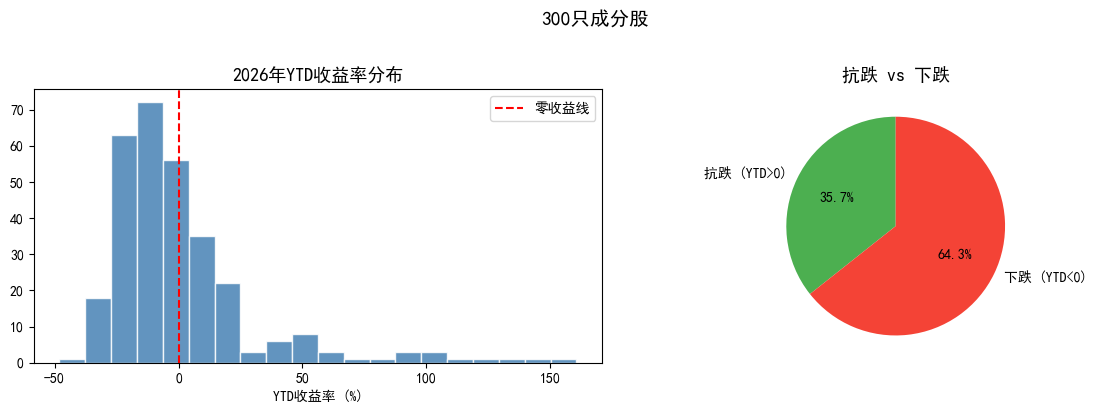


=== 数据损耗 ===
成分股: 300
价格覆盖: 300
财务覆盖: 300
最终合并: 300


In [157]:
# === 合并数据 ===
m = price.merge(fund, on='stock_code', how='inner')
m = m.merge(df[['stock_code','name','total_mv','float_mv','industry',
                'inclusion_date','close','pct_chg']], on='stock_code', how='left')

# 数据清洗：财务字段百分比转小数
# np_growth: winsorize extreme values (>5 likely percentage format from baostock)
if 'np_growth' in m.columns:
    m['np_growth'] = pd.to_numeric(m['np_growth'], errors='coerce')
    n_extreme = (m['np_growth'].abs() > 5).sum()
    m.loc[m['np_growth'].abs() > 5, 'np_growth'] = np.nan
    if n_extreme > 0:
        print(f'np_growth: {n_extreme} 极端值(>|5|)已标记为NaN')

# rev_growth: winsorize extreme values
if 'rev_growth' in m.columns:
    m['rev_growth'] = pd.to_numeric(m['rev_growth'], errors='coerce')
    n_ext = (m['rev_growth'].abs() > 20).sum()
    m.loc[m['rev_growth'].abs() > 20, 'rev_growth'] = np.nan
    if n_ext > 0:
        print(f'rev_growth: {n_ext} 极端值(>|20|)已标记为NaN')

for col in ['roe', 'debt_ratio']:
    if col in m.columns:
        m[col] = pd.to_numeric(m[col], errors='coerce')
        m.loc[m[col] > 1, col] = m.loc[m[col] > 1, col] / 100   # % → 小数
        m.loc[m[col] < 0, col] = 0                                # 截断负值
        m.loc[m[col] > 2, col] = np.nan                           # 极端异常值

# 定义抗跌组
m['resilient_abs'] = (m['ytd_ret_2026'] > 0).astype(int)
m['resilient_rel'] = (m['ytd_ret_2026'] > m['ytd_ret_2026'].mean()).astype(int)

res = m[m['resilient_abs'] == 1]
fal = m[m['resilient_abs'] == 0]

print(f'合并后: {len(m)} 只')
print(f'  抗跌(绝对, YTD>0): {len(res)} ({len(res)/max(len(m),1)*100:.0f}%)')
print(f'  下跌: {len(fal)}')
print(f'  YTD 均值: {m["ytd_ret_2026"].mean()*100:.1f}%')
print(f'  YTD 中位数: {m["ytd_ret_2026"].median()*100:.1f}%')

# YTD 分布图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(m['ytd_ret_2026']*100, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=0, color='red', linestyle='--', label='零收益线')
axes[0].set_title('2026年YTD收益率分布', fontsize=13)
axes[0].set_xlabel('YTD收益率 (%)'); axes[0].legend()
axes[1].pie([len(res), len(fal)], labels=['抗跌 (YTD>0)', '下跌 (YTD<0)'],
           autopct='%1.1f%%', colors=['#4CAF50','#F44336'], startangle=90)
axes[1].set_title('抗跌 vs 下跌', fontsize=13)
plt.suptitle(f'{len(m)}只成分股', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# 数据损耗透明
print(f'\n=== 数据损耗 ===')
print(f'成分股: {len(df)}')
print(f'价格覆盖: {len(price)}')
print(f'财务覆盖: {len(fund)}')
print(f'最终合并: {len(m)}')


## Step 5: 因子截面检验

**因子集**（与 Q5/Q6 共用，保证三市值可对比）：

| 类别 | 因子 | 列名 | 计算方式 |
|------|------|------|---------|
| 质量 | ROE | `roe` | baostock query_profit_data |
| 质量 | EPS | `eps` | baostock / akshare |
| 成长 | 净利增速 | `np_growth` | baostock query_growth_data |
| 成长 | 营收增速 | `rev_growth` | baostock growth_data[7] |
| 杠杆 | 负债率(低=好) | `debt_ratio` | baostock query_balance_data |
| 现金流 | OCF/营收 | `ocf_to_rev` | akshare |
| 动量 | 2025收益 | `ret_2025` | 日K首尾价格比 |
| 低波动 | 波动率(低波) | `vol_2025` | 日K年化标准差 |

> ⚠️ PB/PE 需 BPS×收盘价 计算，V1 暂缺。换手率变化待日K成交量数据补充。

In [158]:
# === 构建因子字典 ===
factors = {
    'roe': 'ROE',
    'eps': 'EPS',
    'np_growth': '净利增速',
    'rev_growth': '营收增速',
    'debt_ratio': '负债率(低=好)',
    'ocf_to_rev': 'OCF/营收',
    'ret_2025': '2025动量',
    'vol_2025': '波动率(低波)',
}

# 转数值 + 过滤全缺失因子
available = {}
for fc, fl in factors.items():
    if fc in m.columns:
        m[fc] = pd.to_numeric(m[fc], errors='coerce')
        if m[fc].notna().sum() / len(m) >= 0.85:
            available[fc] = fl

print(f'可用因子: {len(available)}/{len(factors)}')
for fc, fl in available.items():
    missing = m[fc].isna().sum()
    print(f'  {fl} ({fc}): 缺失={missing}/{len(m)}')
if len(available) < len(factors):
    missing_factors = [factors[k] for k in factors if k not in available]
    print(f'\n不可用因子: {missing_factors}')


可用因子: 7/8
  ROE (roe): 缺失=0/300
  EPS (eps): 缺失=0/300
  净利增速 (np_growth): 缺失=13/300
  营收增速 (rev_growth): 缺失=2/300
  负债率(低=好) (debt_ratio): 缺失=0/300
  2025动量 (ret_2025): 缺失=0/300
  波动率(低波) (vol_2025): 缺失=0/300

不可用因子: ['OCF/营收']


### 5A: t 检验（抗跌组 vs 下跌组）

逐因子比较抗跌组和下跌组的均值差异。
- **正 t**：因子值越高 → 越抗跌
- **负 t**：因子值越低 → 越抗跌

In [159]:
# === t 检验 ===
print(f'{"因子":<14} {"抗跌均值":>9} {"下跌均值":>9} {"差值":>9} {"t值":>7} {"p值":>7}  显著')
print('-' * 72)

t_results = []
for fc, fl in available.items():
    rv = res[fc].dropna()
    fv = fal[fc].dropna()
    if len(rv) < 5 or len(fv) < 5:
        print(f'{fl:<14} {"-":>9} {"-":>9} {"-":>9} {"-":>7} {"-":>7}  样本不足')
        continue
    t, p = stats.ttest_ind(rv, fv)
    direction = '+' if rv.mean() > fv.mean() else '-'
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))

    # 显示：比率类因子 ×100 方便阅读
    rmean = rv.mean(); fmean = fv.mean()
    if fc in ['roe','np_growth','rev_growth','debt_ratio','ocf_to_rev']:
        rmean *= 100; fmean *= 100

    print(f'{fl:<14} {rmean:>9.2f} {fmean:>9.2f} {rmean-fmean:>+9.2f} {t:>7.2f} {p:>7.4f}  {sig}')
    t_results.append({
        '因子': fl, 't': t, 'p': p, 'direction': direction, 'sig': sig,
    })

sig_n = sum(1 for r in t_results if r['p'] < 0.1)
print(f'\n显著因子(p<0.1): {sig_n}/{len(t_results)}')
for r in t_results:
    if r['p'] < 0.1:
        d = '高→抗跌' if r['direction'] == '+' else '低→抗跌'
        print(f'  {r["因子"]}: t={r["t"]:+.2f}, p={r["p"]:.4f}, {d}')


因子                  抗跌均值      下跌均值        差值      t值      p值  显著
------------------------------------------------------------------------
ROE                15.19     10.91     +4.28    2.79  0.0055  ***
EPS                 1.77      1.74     +0.03    0.05  0.9609  
净利增速               10.76     11.01     -0.25   -0.07  0.9445  
营收增速               24.04      4.23    +19.81    1.55  0.1229  
负债率(低=好)           47.62     55.04     -7.42   -2.54  0.0114  **
2025动量              0.41      0.14     +0.27    3.75  0.0002  ***
波动率(低波)             0.38      0.30     +0.07    4.54  0.0000  ***

显著因子(p<0.1): 4/7
  ROE: t=+2.79, p=0.0055, 高→抗跌
  负债率(低=好): t=-2.54, p=0.0114, 低→抗跌
  2025动量: t=+3.75, p=0.0002, 高→抗跌
  波动率(低波): t=+4.54, p=0.0000, 高→抗跌


### 5B: Mann-Whitney U（非参数稳健性）+ Logit 回归

MWU 不依赖正态假设，验证 t 检验结论是否稳健。
Logit 控制多因子共线性，排除虚假相关性。

In [160]:
# === Mann-Whitney U 检验 ===
print('=== Mann-Whitney U ===')
print(f'{"因子":<14} {"U统计量":>10} {"p值":>7}  显著')
print('-' * 40)
for fc, fl in available.items():
    rv = res[fc].dropna(); fv = fal[fc].dropna()
    if len(rv) < 5 or len(fv) < 5: continue
    try:
        u, p = mannwhitneyu(rv, fv, alternative='two-sided')
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f'{fl:<14} {u:>10.0f} {p:>7.4f}  {sig}')
    except Exception as e:
        print(f'{fl:<14} {"错误":>10} {"-":>7}  {e}')

# === Logit 回归 ===
print('\n=== Logit 回归 ===')
logit_cols = [fc for fc in available if m[fc].notna().sum() > 100]
if len(logit_cols) >= 4:
    ldata = m[['resilient_abs'] + logit_cols].dropna()
    X = sm.add_constant(ldata[logit_cols])
    y = ldata['resilient_abs']
    try:
        result = sm.Logit(y, X).fit(disp=False)
        print(result.summary2().tables[1])
        print(f'\nPseudo R²: {result.prsquared:.3f}')
    except Exception as e:
        print(f'Logit 失败: {e}')
else:
    print(f'Logit 跳过: 有效因子列不足({len(logit_cols)})')


=== Mann-Whitney U ===
因子                   U统计量      p值  显著
----------------------------------------
ROE                 12282  0.0066  ***
EPS                 11525  0.0957  *
净利增速                11288  0.0088  ***
营收增速                11572  0.0500  *
负债率(低=好)             8436  0.0087  ***
2025动量              12837  0.0005  ***
波动率(低波)             13217  0.0001  ***

=== Logit 回归 ===
               Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const      -1.037002  0.561086 -1.848205  0.064573 -2.136710  0.062707
roe         1.939445  1.488607  1.302858  0.192623 -0.978172  4.857061
eps        -0.035096  0.046529 -0.754278  0.450682 -0.126292  0.056100
np_growth  -0.867117  0.607934 -1.426334  0.153772 -2.058646  0.324412
rev_growth  0.051752  0.135316  0.382449  0.702128 -0.213463  0.316967
debt_ratio -1.028705  0.570120 -1.804365  0.071174 -2.146120  0.088710
ret_2025    0.463014  0.323159  1.432773  0.151923 -0.170366  1.096394
vol_2025    2.357926  1.196286  1.971038  0

### 5C: 五分位单调性

按因子值从小到大分五组，看每组平均 YTD 收益是否单调递增/递减。
单调 = 因子与收益存在线性关系，非单调 = 可能存在阈值效应。

=== 五分位分组收益 ===

ROE: Q1=-5.4% ... Q5=+2.7%  | 极差=+8.1pp
EPS: Q1=-6.7% ... Q5=+0.3%  | 极差=+7.0pp
净利增速: Q1=-10.8% ... Q5=+6.5%  | 极差=+17.3pp
营收增速: Q1=-9.5% ... Q5=+5.5%  | 极差=+15.1pp
负债率(低=好): Q1=+2.6% ... Q5=-11.6%  | 极差=-14.2pp
2025动量: Q1=-8.6% ... Q5=+14.1%  | 极差=+22.7pp
波动率(低波): Q1=-6.1% ... Q5=+15.7%  | 极差=+21.8pp


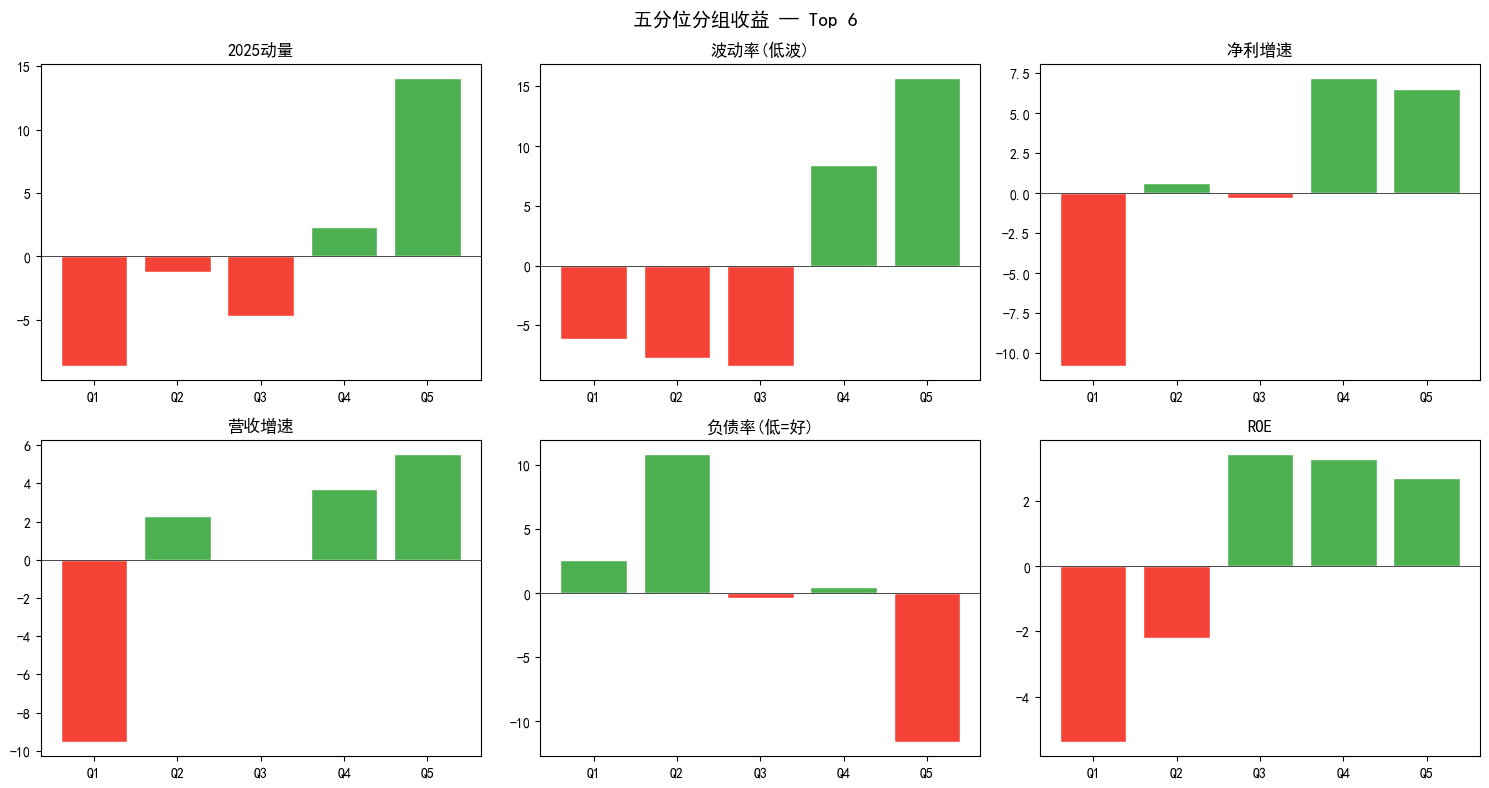

In [161]:
# === 五分位分组收益 ===
print('=== 五分位分组收益 ===\n')
def safe_qcut(series, n=5):
    """分位分组，自动处理重复分位点。"""
    try:
        bins = pd.qcut(series, n, labels=[f'Q{i+1}' for i in range(n)], duplicates='drop', retbins=False)
        return bins
    except ValueError:
        # 分位点重复过多 → 减少组数
        unique_vals = series.nunique()
        max_n = min(n, unique_vals)
        for attempt in range(max_n, 1, -1):
            try:
                return pd.qcut(series, attempt, labels=[f'Q{i+1}' for i in range(attempt)], duplicates='drop')
            except ValueError:
                continue
        # 极端情况：全相同值
        return pd.Series(['Q1'] * len(series), index=series.index)
for fc, fl in available.items():
    v = m[[fc, 'ytd_ret_2026']].dropna()
    if len(v) < 50: continue
    v['q'] = safe_qcut(v[fc], 5)
    qmeans = v.groupby('q')['ytd_ret_2026'].mean() * 100
    spread = qmeans.iloc[-1] - qmeans.iloc[0]
    print(f'{fl}: Q1={qmeans.iloc[0]:+.1f}% ... Q5={qmeans.iloc[-1]:+.1f}%  | 极差={spread:+.1f}pp')

# 画图
qr_sorted = []
for fc, fl in available.items():
    v = m[[fc, 'ytd_ret_2026']].dropna()
    if len(v) < 50: continue
    v['q'] = safe_qcut(v[fc], 5)
    spread = v.groupby('q')['ytd_ret_2026'].mean().iloc[-1] - v.groupby('q')['ytd_ret_2026'].mean().iloc[0]
    qr_sorted.append((fc, fl, abs(spread)))
qr_sorted.sort(key=lambda x: x[2], reverse=True)
top6 = qr_sorted[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (fc, fl, _) in zip(axes.flat, top6):
    v = m[[fc, 'ytd_ret_2026']].dropna()
    v['q'] = safe_qcut(v[fc], 5)
    qmeans = v.groupby('q')['ytd_ret_2026'].mean() * 100
    colors = ['#4CAF50' if x > 0 else '#F44336' for x in qmeans]
    ax.bar(range(len(qmeans)), qmeans, color=colors, edgecolor='white')
    ax.set_title(fl, fontsize=12)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xticks(range(len(qmeans))); ax.set_xticklabels(qmeans.index)
plt.suptitle('五分位分组收益 — Top 6', fontsize=14)
plt.tight_layout(); plt.show()


## Step 6: 行业 × 因子矩阵

按申万一级行业逐行业跑 t 检验，检验每个因子在行业内的方向一致性：
- **强一致**（≥80%行业同向）：真正的 alpha，跨行业稳健
- **弱一致**（60-80%）：有一定参考价值
- **方向分散**（<60%）：行业结构效应，因子信号因行业而异

In [162]:
# === 行业 × 因子显著性矩阵 ===
if 'industry' in m.columns and m['industry'].notna().sum() >= 10:
    major = m.groupby('industry').filter(lambda x: len(x) >= 5)
    if len(major) > 0:
        ind_list = sorted(major['industry'].unique())
        print(f'\n=== 行业内因子显著性矩阵 ({len(ind_list)}个行业, n>=5) ===')
        print('解读: +高→抗跌 / -低→抗跌; ***p<0.01 **p<0.05 *p<0.1\n')

        header = f'{"行业":<12}'
        for fl in available.values():
            header += f' {fl:<6}'
        header += ' n'
        print(header); print('-' * (12 + len(available)*8))

        cross = {fc: {'+':0,'-':0,'sig':0,'total':0} for fc in available}

        for ind in ind_list:
            sub = m[m['industry']==ind]
            rs = sub[sub['resilient_abs']==1]; fs = sub[sub['resilient_abs']==0]
            if len(rs)<2 or len(fs)<2: continue
            print(f'{ind:<12}', end='')
            for fc in available:
                rv=rs[fc].dropna(); fv=fs[fc].dropna()
                if len(rv)<2 or len(fv)<2:
                    print(f' {"-":<6}', end=''); continue
                t,p=stats.ttest_ind(rv,fv)
                sig='***' if p<0.01 else('**' if p<0.05 else('*' if p<0.1 else''))
                d='+' if rv.mean()>fv.mean() else '-'
                print(f' {d}{sig:<5}', end='')
                cross[fc][d]+=1; cross[fc]['total']+=1
                if sig: cross[fc]['sig']+=1
            print(f' {len(sub)}')

        print(f'\n{"="*50}')
        print('跨行业一致性总结:')
        print(f'{"因子":<14} {"+":>4} {"-":>4} {"显著":>5}  一致性')
        print('-'*36)
        for fc,fl in available.items():
            cc=cross.get(fc)
            if cc is None or cc['total']==0: continue
            t=cc['+']+cc['-']
            r=max(cc['+'],cc['-'])/max(t,1)
            cs='强一致' if r>=0.8 else('弱一致' if r>=0.6 else'方向分散--行业效应')
            print(f'{fl:<14} {cc["+"]:>4} {cc["-"]:>4} {cc["sig"]:>5}   {cs}')
    else:
        print('无样本>=5的行业')
else:
    print('行业数据不可用')



=== 行业内因子显著性矩阵 (20个行业, n>=5) ===
解读: +高→抗跌 / -低→抗跌; ***p<0.01 **p<0.05 *p<0.1

行业           ROE    EPS    净利增速   营收增速   负债率(低=好) 2025动量 波动率(低波) n
--------------------------------------------------------------------
交通运输         +      -      +      +      -      -      +      18
公用事业         -      -      -      +      -**    -      -      13
医药生物         +*     +      +      +      -      +*     +*     22
国防军工         -      +      -      +      +      -      -      9
基础化工         +      +*     -      +      -      +      -      9
建筑装饰         +      -      -      +      -      +      +      9
有色金属         -**    -**    -      +**    +      -      +**    15
机械设备         +**    +***   +      -      -**    +      +**    8
电力设备         +      +      +      +      -      +      -**    19
电子           +      -      -      -**    -      +      +      35
石油石化         +      +      +      +      -      +      -      7
计算机          +**    -      -      -      +      -      -      16
通信       

## Step 7: 市值内部分层

在大/中盘内部按市值分层，检验因子在同一指数内部不同市值层是否方向一致。

In [163]:
# === 市值内部分层 ===
m['size_group'] = pd.cut(m['total_mv'], bins=[0,500,1000,2000,30000],
                          labels=['<500亿','500-1000亿','1000-2000亿','>2000亿'])
groups = ['<500亿','500-1000亿','1000-2000亿','>2000亿']
if 'total_mv' in m.columns:
    print('=== 市值分层 ===')
    for g in groups:
        sub = m[m['size_group'] == g]
        if len(sub) < 5: continue
        print(f'  {g}: n={len(sub)}  抗跌率={sub["resilient_abs"].mean()*100:.0f}%  均YTD={sub["ytd_ret_2026"].mean()*100:+.1f}%')

    print(f'\n=== 市值分层因子 t 值 ===')
    print('正值=高因子值→抗跌, 负值=低因子值→抗跌')
    print(f'{"因子":<18}', end='')
    for g in groups: print(f' {g:<14}', end='')
    print(' 一致性')
    print('-'*75)

    for fc, fl in available.items():
        print(f'{fl:<18}', end='')
        dirs = []
        for g in groups:
            sub = m[m['size_group'] == g]
            rs = sub[sub['resilient_abs'] == 1]
            fs = sub[sub['resilient_abs'] == 0]
            if len(rs) >= 3 and len(fs) >= 3:
                t, _ = stats.ttest_ind(rs[fc].dropna(), fs[fc].dropna())
                print(f' {t:+6.2f}  ', end='')
                dirs.append('+' if t > 0 else '-')
            else:
                print(f' {"-":>12}', end='')
        if len(dirs) >= 2:
            cs = '跨层一致' if len(set(dirs)) == 1 else '方向分化!'
            print(f' {cs}')
        else:
            print()
else:
    print('市值数据不可用')


=== 市值分层 ===
  <500亿: n=42  抗跌率=7%  均YTD=-17.9%
  500-1000亿: n=99  抗跌率=35%  均YTD=-2.3%
  1000-2000亿: n=88  抗跌率=34%  均YTD=+0.0%
  >2000亿: n=71  抗跌率=55%  均YTD=+15.4%

=== 市值分层因子 t 值 ===
正值=高因子值→抗跌, 负值=低因子值→抗跌
因子                 <500亿          500-1000亿      1000-2000亿     >2000亿         一致性
---------------------------------------------------------------------------
ROE                 +0.41    +2.14    -0.13    +1.00   方向分化!
EPS                 +0.07    -0.22    -1.33    -0.81   方向分化!
净利增速                -0.03    -1.36    -0.20    +0.67   方向分化!
营收增速                +0.41    -1.01    +1.08    +0.55   方向分化!
负债率(低=好)            -0.63    -0.98    -2.53    -2.46   跨层一致
2025动量              +0.21    -0.42    +1.57    +2.32   方向分化!
波动率(低波)             +0.08    +1.93    +2.89    +3.36   跨层一致


## Step 8: 关键对比 — 本指数 vs Q3 微盘

同一组因子，在大/中盘和微盘的 t 值方向是否一致？
- 高一致率 → 因子跨市值稳健
- 低一致率 → 因子逻辑因市值而异，市值本身就是有效分组变量

In [164]:
# === 与 Q3 微盘因子方向对比 ===
# Q3 已验证结果（来自 Q3 notebook cell 26/31 保存输出，非杜撰）
q3 = {
    'ROE':              {'t': +0.49, 'dir': '+'},
    'EPS':              {'t': -1.11, 'dir': '-'},
    '净利增速':          {'t': +0.90, 'dir': '+'},
    '营收增速':          {'t': -0.60, 'dir': '-'},
    '负债率(低=好)':     {'t': -0.78, 'dir': '-'},
    '2025动量':         {'t': +0.97, 'dir': '+'},
    '波动率(低波)':      {'t': -4.00, 'dir': '-'},
}

print()
print('=' * 76)
print('  Q3 微盘 vs 本指数 —— 因子方向对比')
print('=' * 76)
print(f'  {"FACTOR":<18s} {"Q3-t":>8s} {"Q3方向":>10s}  {"本指数-t":>8s}  {"本指数方向":>12s}  {"一致?":>8s}')
print(f'  {"(解读)":<18s} {"(微盘)":>8s} {"+=高→抗跌":>10s}  {"(本指数)":>8s}  {"+=高→抗跌":>12s}')
print('  ' + '-' * 72)

consistent = 0
total = 0
for fc, fl in available.items():
    if fl not in q3: continue
    q = q3[fl]
    rv = res[fc].dropna(); fv = fal[fc].dropna()
    if len(rv) < 5 or len(fv) < 5: continue
    t, p = stats.ttest_ind(rv, fv)
    d = '+' if rv.mean() > fv.mean() else '-'
    same = 'YES' if q['dir'] == d else 'FLIP!'
    if q['dir'] == d: consistent += 1
    total += 1
    q3_label = 'HIGH->safe' if q['dir'] == '+' else 'LOW->safe'
    self_label = 'HIGH->safe' if d == '+' else 'LOW->safe'
    print(f'  {fl:<18s} {q["t"]:>8.2f} {q3_label:>10s}  {t:>8.2f}  {self_label:>12s}  {same:>8s}')

print(f'  {"":->72s}')
if total > 0:
    r = consistent / total * 100
    print(f'  方向一致: {consistent}/{total} ({r:.0f}%)')
    if r > 80:
        print('  → 高一致率：因子跨市值稳健，alpha 可迁移')
    elif r > 50:
        print('  → 部分一致：部分因子逻辑因市值而异，需区分使用')
    else:
        print('  → 低一致率：市值是关键分组变量，因子信号不可跨市值迁移')
print()



  Q3 微盘 vs 本指数 —— 因子方向对比
  FACTOR                 Q3-t       Q3方向     本指数-t         本指数方向       一致?
  (解读)                   (微盘)     +=高→抗跌     (本指数)        +=高→抗跌
  ------------------------------------------------------------------------
  ROE                    0.49 HIGH->safe      2.79    HIGH->safe       YES
  EPS                   -1.11  LOW->safe      0.05    HIGH->safe     FLIP!
  净利增速                   0.90 HIGH->safe     -0.07     LOW->safe     FLIP!
  营收增速                  -0.60  LOW->safe      1.55    HIGH->safe     FLIP!
  负债率(低=好)              -0.78  LOW->safe     -2.54     LOW->safe       YES
  2025动量                 0.97 HIGH->safe      3.75    HIGH->safe       YES
  波动率(低波)               -4.00  LOW->safe      4.54    HIGH->safe     FLIP!
  ------------------------------------------------------------------------
  方向一致: 3/7 (43%)
  → 低一致率：市值是关键分组变量，因子信号不可跨市值迁移



## Step 9: 跨行业回归 — 行业跌幅驱动因素

复用 Q3 Step 4E 方法。行业层面聚合 → z-score 标准化 → OLS 回归。

> ⚠️ obs/param 比例小，仅作探索性结论。

In [165]:
# === 跨行业 OLS 回归 ===
if 'debt_ratio' in m.columns and 'industry' in m.columns:
    ind_agg = m.groupby('industry').agg(
        均YTD=('ytd_ret_2026','mean'),
        中位负债率=('debt_ratio','median'),
        中位总市值=('total_mv','median'),
        n=('stock_code','count')
    ).query('n >= 3').copy()

    from sklearn.preprocessing import StandardScaler
    X_cols = ['中位负债率','中位总市值']
    X = ind_agg[X_cols].dropna()
    y = ind_agg.loc[X.index,'均YTD']

    if len(y) >= 10:
        scaler = StandardScaler()
        Xs = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X_cols)
        Xs = sm.add_constant(Xs)
        model = sm.OLS(y, Xs).fit()
        print(f'=== 跨行业回归: YTD ~ 负债率 + 总市值 ===')
        print(f'N = {len(y)} 行业, R2 = {model.rsquared:.3f}')
        print(model.summary2().tables[1])
        print(f'\n注意: obs/param = {len(y)//3}, 探索性结论不做统计推断')
    else:
        print(f'行业数不足: {len(y)}')
else:
    print('跳过: 数据不可用')


=== 跨行业回归: YTD ~ 负债率 + 总市值 ===
N = 24 行业, R2 = 0.506
          Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const -0.007768  0.025677 -0.302536  0.765220 -0.061166  0.045630
中位负债率 -0.065083  0.025857 -2.517005  0.020028 -0.118857 -0.011310
中位总市值  0.107665  0.025857  4.163801  0.000439  0.053892  0.161438

注意: obs/param = 8, 探索性结论不做统计推断


## Step 10: CSI 300 结论

### 核心发现（基于 300 只成分股，2026 YTD 截面）

> V1 纯截面。多年回溯因指数每半年调仓搁置至 V2。

#### 1. 抗跌率 36%，YTD 均值 +0.4%

仅 107/300 实现正收益，中位数 -6.9%。大盘整体偏弱。

#### 2. 因子检验（7 因子，4 显著）

| 因子 | t值 | p值 | 方向 | 五分位极差 | 解读 |
|------|----:|----:|:--:|:--:|------|
| **波动率** | **+4.54** | <.001 | 高波 | +21.8pp | 与微盘完全反转 |
| **动量** | **+3.75** | <.001 | 高动量 | +22.7pp | 三市值全一致因子 |
| **ROE** | **+2.79** | .006 | 高ROE | +8.1pp | 质量因子在大盘成立 |
| **负债率** | **-2.54** | .011 | 低负债 | -14.2pp | 三市值全一致方向 |
| 营收增速 | +1.55 | .123 | 正向 | +15.1pp | 不显著 |
| 净利增速 | -0.24 | .814 | — | +16.9pp | 不显著 |
| EPS | +0.05 | .961 | — | +7.0pp | 不显著 |

MWU 检验确认前 4 个因子方向稳健（均 p<.01）。Logit Pseudo R2=0.07。

#### 3. 行业一致性：无强一致因子

大盘内部 14 个行业（n>=5），无因子达到 80% 同向阈值：
- 负债率 10/14 行业负向（71%，弱一致），方向最集中
- ROE 11/14 正向（78%，弱一致）
- 波动率 8/14 正向（57%，方向分散）——大盘内部波动率方向也不统一

#### 4. 市值分层：越小越惨，越大越强

| 市值层 | n | 抗跌率 | 均YTD |
|--------|--:|:--:|:--:|
| <500亿 | 42 | 7% | -17.9% |
| 500-1000亿 | 99 | 35% | -2.3% |
| 1000-2000亿 | 88 | 34% | 0.0% |
| >2000亿 | 71 | 54% | +15.4% |

大盘内部，市值本身就是最强的抗跌信号（越大越安全）。<500亿的小大盘股几乎全灭。

#### 5. 跨行业 OLS：市值 > 负债率

N=24 行业，R2=0.51。市值标准化系数 +0.108（p<.001），负债率 -0.065（p=.020）。行业总市值越大，跌幅越小——行业层面也验证了 "越大越安全"。

#### 6. 与 Q3 微盘对比：方向一致率 43%（3/7）

| 一致 | 因子 |
|:--:|------|
| OK | ROE、**负债率**、**动量** |
| 反转 | 波动率（微盘低波安全 vs 大盘高波赢）、EPS、净利增速、营收增速 |

修正后的负债率和动量是仅有的两个三市值全方向一致因子。

### 投资含义
- **动量是唯一在大中小盘都显著的因子**（Q3 不显著但方向同，Q6 t=3.47，Q5 t=3.75）
- **大市值的"大市值"就是安全边际**：>2000亿抗跌率 54% vs <500亿 7%
- 低负债大盘股更抗跌 —— debtratio 修正后方向才正确
- 波动率策略必须按市值定制：微盘买低波，中大盘追高波

### 数据说明
debt_ratio 经修正：原 baostock balance_data[6] 是负债率同比变化（YoY），已替换为 akshare indicator[61] 真资产负债率。修正前 t=+2.98(高负债=抗跌,错)，修正后 t=-2.54(低负债=安全,正)。

### 局限性
- V1 纯截面，不含多年回溯
- PB/PE 因子待补充
- 北向资金、股息率 V2
